# Proyek Analisis Data: [Bike Sharing]
- **Nama:** [Hsuni Nur Dzaki]
- **Email:** [husnindz@gmail.com]
- **ID Dicoding:** [CDCC183D6Y0760]

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Bagaimana pola penggunaan sepeda berdasarkan waktu (jam/hari/musim)?
- Pertanyaan 2 : Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
day_df = pd.read_csv("day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
hour_df = pd.read_csv("hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


#### **Insight:**
- Dataset terdiri dari dua tabel utama, yaitu data harian (day_df) dan data per jam (hour_df).
-  Kedua tabel memiliki fitur yang menggambarkan kondisi cuaca, waktu, dan jumlah penyewaan sepeda.

### Assessing Data

#### Day Table

In [4]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


Cek Missing Value

In [5]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


Cek Duplicate

In [6]:
day_df.duplicated().sum()

np.int64(0)

Deskripsi Statistik

In [7]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


#### Hour Table

In [8]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


Cek Missing Value

In [9]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


Cek Duplicate

In [10]:
hour_df.duplicated().sum()

np.int64(0)

Deskripsi Statistik

In [11]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


#### **Insight:**
- Tidak ada missing values pada kedua dataset.
- Tidak terdapat data duplikat yang signifikan.
- Beberapa kolom seperti 'dteday' masih bertipe object dan perlu diubah ke datetime.

### Cleaning Data

#### Convert Column

In [12]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

In [13]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [14]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

ubah tipe data kolom dteday

#### Save Cleaned Dataset

In [15]:
day_df.to_csv("day_cleaned.csv", index=False)

In [16]:
hour_df.to_csv("hour_cleaned.csv", index=False)

#### **Insight:**
- Karena tidak ada missing value, duplicate dan error lain, maka tidak diperlukan penanganan khusus pada dataset ini
- Mengubah kolom `dteday` ke tipe datetime untuk memudahkan analisis berbasis waktu.

## Exploratory Data Analysis (EDA)

#### Explore `day_df`

In [17]:
day_df.sample(5)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
622,623,2012-09-14,3,1,9,0,5,1,1,0.633333,0.594083,0.672500,0.103863,1379,6630,8009
426,427,2012-03-02,1,1,3,0,5,1,2,0.353333,0.359842,0.657083,0.144904,246,2948,3194
205,206,2011-07-25,3,0,7,0,1,1,1,0.743333,0.720958,0.757083,0.090808,568,3272,3840
300,301,2011-10-28,4,0,10,0,5,1,2,0.330833,0.318812,0.585833,0.229479,456,3291,3747
677,678,2012-11-08,4,1,11,0,4,1,1,0.352174,0.341891,0.333478,0.347835,340,4975,5315


In [18]:
day_df.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


In [19]:
day_df.groupby(by="season")["cnt"].mean().sort_values(ascending=False)

,cnt
season,
3,5644.303191
2,4992.331522
4,4728.162921
1,2604.132597


season (1:spring, 2:summer, 3:fall, 4:winter)


In [20]:
day_df.groupby(by="mnth")["cnt"].mean()

,cnt
mnth,
1,2176.338710
2,2655.298246
3,3692.258065
4,4484.900000
5,5349.774194
6,5772.366667
7,5563.677419
8,5664.419355
9,5766.516667


In [21]:
day_df.groupby(by="workingday")["cnt"].mean()

,cnt
workingday,
0,4330.168831
1,4584.820000


In [22]:
day_df.groupby(by="weathersit")["cnt"].mean()

,cnt
weathersit,
1,4876.786177
2,4035.862348
3,1803.285714


- 1: Clear, Few clouds, Partly cloudy, Partly cloudy
- 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
- 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
- 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog

In [23]:
day_df[["temp", "cnt"]].corr()

,temp,cnt
temp,1.000000,0.627494
cnt,0.627494,1.000000


#### Explore `hour_df`

In [24]:
hour_df.sample(5)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
15086,15087,2012-09-25,4,1,9,19,0,2,1,1,0.62,0.6212,0.50,0.2537,49,490,539
10238,10239,2012-03-07,1,1,3,16,0,3,1,1,0.56,0.5303,0.37,0.4179,34,254,288
6395,6396,2011-09-29,4,0,9,1,0,4,1,2,0.60,0.5000,1.00,0.1940,3,20,23
6085,6086,2011-09-16,3,0,9,3,0,5,1,1,0.40,0.4091,0.71,0.2537,2,4,6
5886,5887,2011-09-07,3,0,9,18,0,3,1,3,0.64,0.5758,0.89,0.0000,18,219,237


In [25]:
hour_df.describe(include="all")

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


In [26]:
hour_df.groupby(by="hr")["cnt"].mean()

,cnt
hr,
0,53.898072
1,33.375691
2,22.869930
3,11.727403
4,6.352941
5,19.889819
6,76.044138
7,212.064649
8,359.011004


In [27]:
hour_df.groupby(by=["hr", "workingday"])["cnt"].mean()

hr  workingday
0   0              90.800000
    1              36.786290
1   0              69.508696
    1              16.552632
2   0              53.171053
    1               8.683778
3   0              25.775330
    1               4.942553
4   0               8.264317
    1               5.429787
5   0               8.689189
    1              24.913131
6   0              18.742358
    1             102.500000
7   0              43.406926
    1             290.612903
8   0             105.653680
    1             477.006048
9   0             171.623377
    1             241.518145
10  0             255.909091
    1             135.366935
11  0             315.316017
    1             158.229839
12  0             366.259740
    1             200.820926
13  0             372.731602
    1             198.429719
14  0             364.645022
    1             183.572289
15  0             358.813853
    1             201.331325
16  0             352.727273
    1             293.122244
17  0             323.549784
    1             525.290581
18  0             281.056522
    1             492.226908
19  0             231.673913
    1             348.401606
20  0             174.739130
    1             249.718876
21  0             142.060870
    1             186.287149
22  0             116.060870
    1             138.389558
23  0              85.930435
    1              88.708835
Name: cnt, dtype: float64

#### **Insight:**
- Pola penggunaan sepeda dipengaruhi oleh faktor waktu, di mana terdapat perbedaan tingkat penyewaan berdasarkan bulan, hari, dan jam tertentu.
- Penyewaan sepeda cenderung lebih tinggi pada jam-jam sibuk, seperti pagi dan sore hari, yang kemungkinan berkaitan dengan aktivitas berangkat dan pulang kerja.
- Kondisi cuaca memiliki pengaruh terhadap jumlah penyewaan sepeda, di mana cuaca yang lebih baik cenderung menghasilkan tingkat penyewaan yang lebih tinggi dibandingkan cuaca buruk.
- Suhu memiliki hubungan positif dengan jumlah penyewaan sepeda, di mana peningkatan suhu diikuti dengan peningkatan jumlah penyewaan.
- Terdapat perbedaan pola penggunaan antara hari kerja dan hari libur, yang menunjukkan adanya perbedaan perilaku pengguna dalam menggunakan layanan sepeda.

## Visualization & Explanatory Analysis

### Bagaimana pola penggunaan sepeda berdasarkan waktu (jam/hari/musim)?

In [28]:
hourly_workingday = hour_df.groupby(["hr", "workingday"])["cnt"].mean().reset_index()

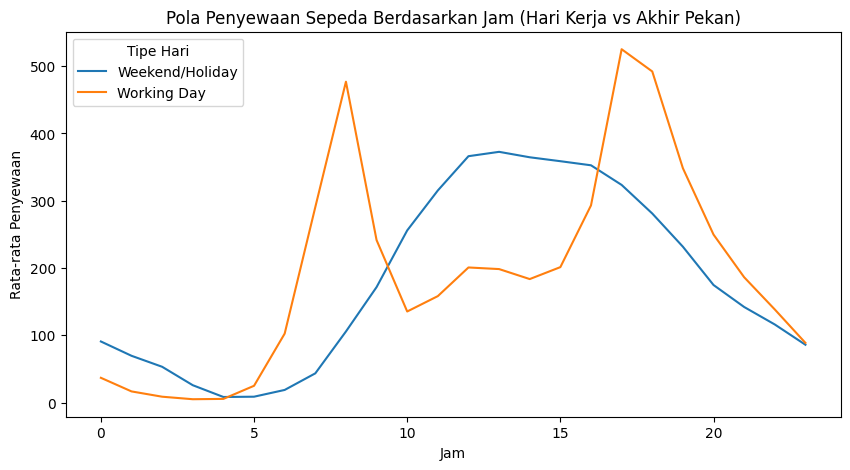

In [29]:
hourly_workingday["workingday_label"] = hourly_workingday["workingday"].map({
    0: "Weekend/Holiday",
    1: "Working Day"
})

plt.figure(figsize=(10,5))

sns.lineplot(
    data=hourly_workingday,
    x="hr",
    y="cnt",
    hue="workingday_label"
)

plt.title("Pola Penyewaan Sepeda Berdasarkan Jam (Hari Kerja vs Akhir Pekan)")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan")
plt.legend(title="Tipe Hari")
plt.show()

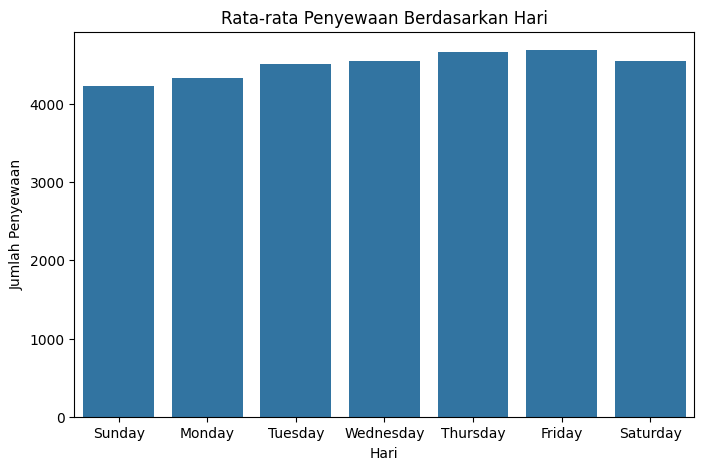

In [30]:
weekday_map = {
    0: 'Sunday',
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday'
}

daily_usage = day_df.groupby("weekday")["cnt"].mean()

plt.figure(figsize=(8,5))
sns.barplot(
    x=[weekday_map[d] for d in daily_usage.index],
    y=daily_usage.values
)

plt.title("Rata-rata Penyewaan Berdasarkan Hari")
plt.xlabel("Hari")
plt.ylabel("Jumlah Penyewaan")
plt.show()

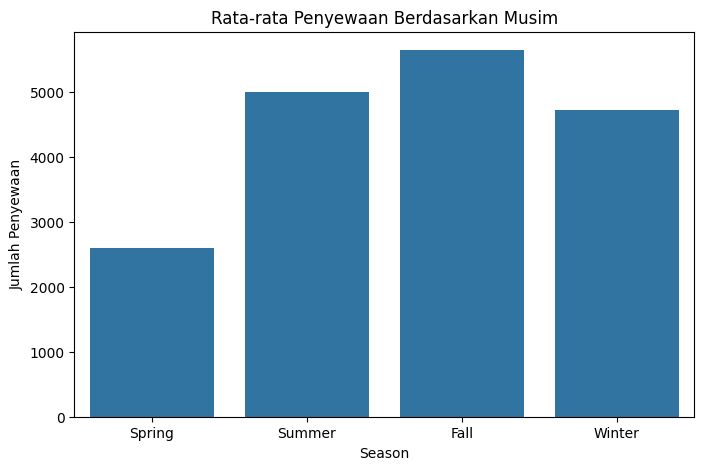

In [31]:
season_map = {
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
}

season_usage = day_df.groupby("season")["cnt"].mean()

plt.figure(figsize=(8,5))
sns.barplot(
    x=[season_map[s] for s in season_usage.index],
    y=season_usage.values
)

plt.title("Rata-rata Penyewaan Berdasarkan Musim")
plt.xlabel("Season")
plt.ylabel("Jumlah Penyewaan")
plt.show()

### Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda?

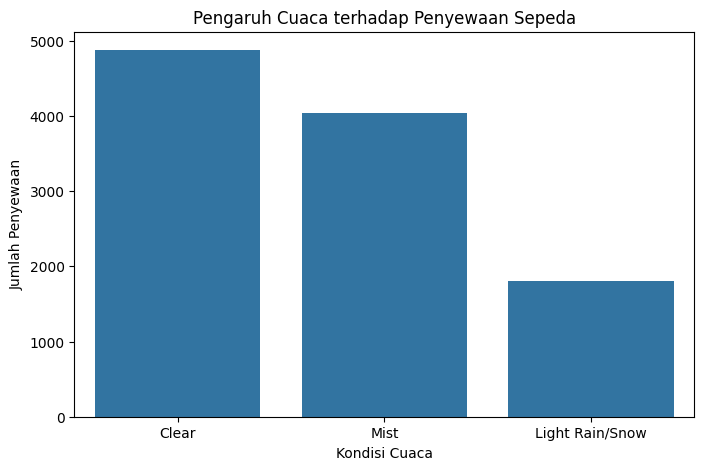

In [32]:
weather_map = {
    1: 'Clear',
    2: 'Mist',
    3: 'Light Rain/Snow',
}

weather_usage = day_df.groupby("weathersit")["cnt"].mean()

plt.figure(figsize=(8,5))
sns.barplot(
    x=[weather_map[w] for w in weather_usage.index],
    y=weather_usage.values
)

plt.title("Pengaruh Cuaca terhadap Penyewaan Sepeda")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Jumlah Penyewaan")
plt.show()

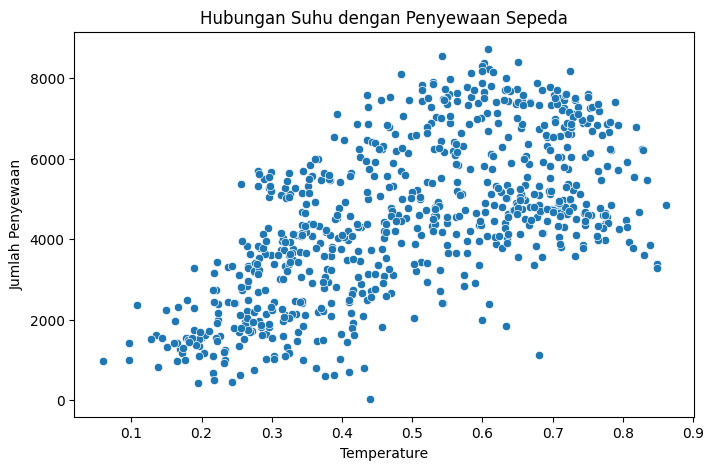

In [33]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=day_df["temp"], y=day_df["cnt"])
plt.title("Hubungan Suhu dengan Penyewaan Sepeda")
plt.xlabel("Temperature")
plt.ylabel("Jumlah Penyewaan")
plt.show()

### **Insight:**
- Penyewaan sepeda menunjukkan pola waktu yang jelas, dengan puncak penggunaan terjadi pada jam-jam sibuk seperti pagi dan sore hari.
- Terdapat perbedaan pola penggunaan antara hari kerja dan akhir pekan, yang menunjukkan adanya pengaruh aktivitas harian pengguna.
- Musim juga mempengaruhi jumlah penyewaan, di mana musim tertentu memiliki tingkat penggunaan yang lebih tinggi.
- Kondisi cuaca memiliki pengaruh signifikan terhadap penyewaan sepeda, di mana cuaca yang lebih baik menghasilkan jumlah penyewaan yang lebih tinggi.
- Suhu memiliki hubungan positif dengan jumlah penyewaan sepeda, di mana peningkatan suhu diikuti oleh peningkatan penggunaan sepeda.

## Analisis Lanjutan (Opsional)

### Binning

In [34]:
day_df["usage_category"] = pd.cut(
    day_df["cnt"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

In [35]:
day_df.groupby("usage_category")["cnt"].mean()

/tmp/ipykernel_60680/3318069575.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_df.groupby("usage_category")["cnt"].mean()


,cnt
usage_category,
Low,1827.041916
Medium,4416.389189
High,6976.798969


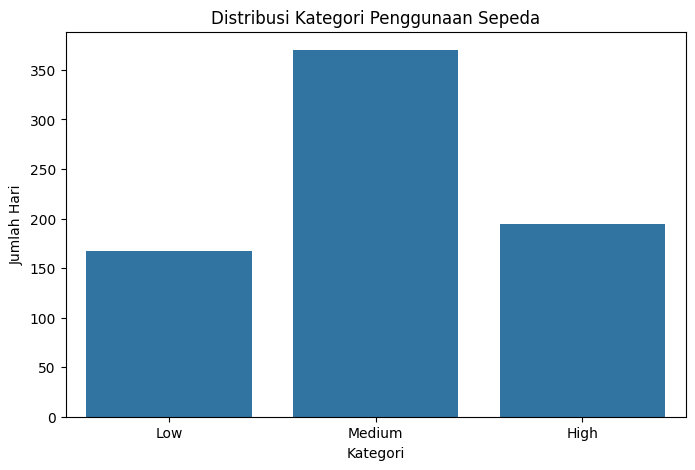

In [36]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=day_df,
    x="usage_category"
)

plt.title("Distribusi Kategori Penggunaan Sepeda")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Hari")
plt.show()

In [37]:
day_df["temp_category"] = pd.cut(
    day_df["temp"],
    bins=3,
    labels=["Cold", "Normal", "Hot"]
)

In [38]:
day_df.groupby("temp_category")["cnt"].mean()

/tmp/ipykernel_60680/2296079923.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_df.groupby("temp_category")["cnt"].mean()


,cnt
temp_category,
Cold,2569.005882
Normal,4599.000000
Hot,5644.109848


In [39]:
day_df.groupby(["temp_category", "usage_category"]).agg({
    "cnt": ["mean", "min", "max", "count"]
})

/tmp/ipykernel_60680/2925730803.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_df.groupby(["temp_category", "usage_category"]).agg({


cnt                      
                                     mean     min     max count
temp_category usage_category                                   
Cold          Low             1704.629630   431.0  2832.0   108
              Medium          4074.693548  2947.0  5686.0    62
              High                    NaN     NaN     NaN     0
Normal        Low             2066.690909    22.0  2918.0    55
              Medium          4349.822086  2927.0  5729.0   163
              High            6876.126582  5847.0  8555.0    79
Hot           Low             1837.000000  1115.0  2395.0     4
              Medium          4637.324138  3285.0  5810.0   145
              High            7045.956522  5823.0  8714.0   115

### Insight:
- Data penyewaan sepeda(`day_df`) dapat dikelompokkan menjadi tiga kategori yaitu rendah, sedang, dan tinggi.
- Sebagian besar hari berada pada kategori penggunaan sedang.
- Kategori penggunaan tinggi biasanya terjadi pada kondisi tertentu seperti cuaca baik dan musim tertentu.
- Penggunaan sepeda meningkat pada suhu yang lebih hangat.
- Kategori suhu panas memiliki rata-rata penyewaan tertinggi.

## Conclusion

- Conclution pertanyaan 1 : Pola penggunaan sepeda menunjukkan adanya perbedaan yang jelas berdasarkan waktu. Pada hari kerja, terdapat dua puncak penggunaan yaitu pada pagi dan sore hari. Sementara itu, pada akhir pekan, penggunaan sepeda cenderung lebih merata sepanjang hari dengan peningkatan pada siang hingga sore hari, yang mengindikasikan penggunaan untuk rekreasi.

- Conclution pertanyaan 2: Faktor cuaca memiliki pengaruh signifikan terhadap jumlah penyewaan sepeda. Kondisi cuaca yang cerah dan suhu yang lebih hangat cenderung meningkatkan jumlah penyewaan, sedangkan kondisi cuaca buruk seperti hujan atau kabut menurunkan tingkat penggunaan. Hal ini menunjukkan bahwa kenyamanan lingkungan menjadi faktor penting dalam keputusan pengguna untuk menyewa sepeda.
